In [1]:
import pandas as pd
import numpy as np

In [2]:
url = 'https://raw.githubusercontent.com/skathirmani/datasets/main/employees_attrition.csv'
employees = pd.read_csv(url)
employees.shape

(1470, 35)

In [18]:
employees.isna().sum().sum()

0

# Data Visualization
Reference: http://i2.wp.com/insightextractor.com/wp-content/uploads/2012/08/chart-chooser-data-visualization.png

## Distribution analysis

In [16]:
#cols = ['Age', 'MonthlyIncome']
#employees[cols].describe()

employees['MonthlyIncome'].describe()

count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64

In [22]:
# 25th percentile, 1st Quartile
employees[employees['MonthlyIncome'] <= 2911].shape[0] / employees.shape[0] * 100

25.102040816326532

In [23]:
# 50th percentile, 2nd Quartile, Median
employees[employees['MonthlyIncome'] <= 4919].shape[0] / employees.shape[0] * 100

50.0

In [24]:
# 75th percentile, 3rd Quartile
employees[employees['MonthlyIncome'] <= 8379].shape[0] / employees.shape[0] * 100

74.96598639455783

In [29]:
employees['MonthlyIncome'].quantile([0, 0.25, 0.5, 0.75, 0.95, 1])

0.00     1009.00
0.25     2911.00
0.50     4919.00
0.75     8379.00
0.95    17821.35
1.00    19999.00
Name: MonthlyIncome, dtype: float64

### Box Plot

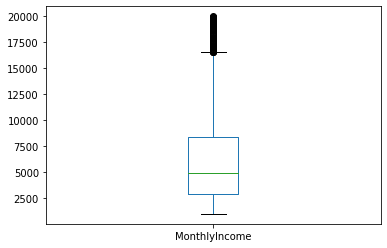

In [31]:
employees['MonthlyIncome'].plot.box();

In [37]:
q1 = employees['MonthlyIncome'].quantile([0.25]).loc[0.25]
q3 = employees['MonthlyIncome'].quantile([0.75]).loc[0.75]
iqr = q3 - q1
lw = q1 - 1.5 * iqr
uw = q3 + 1.5 * iqr
uw

16581.0

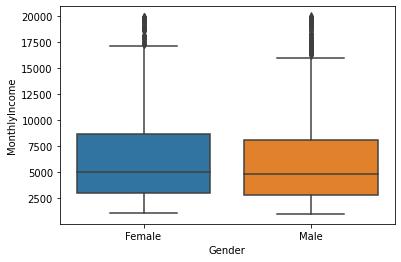

In [43]:
import seaborn as sns
sns.boxplot(data=employees, y='MonthlyIncome', x='Gender');

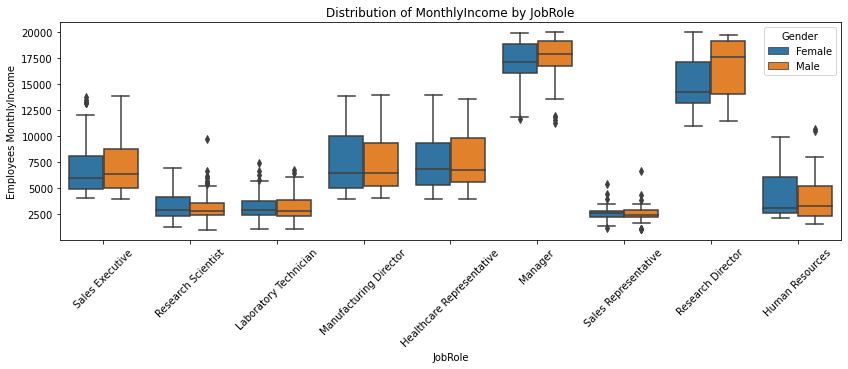

In [85]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 4))
sns.boxplot(data=employees, y='MonthlyIncome', x='JobRole', hue='Gender')
plt.title('Distribution of MonthlyIncome by JobRole')
plt.ylabel('Employees MonthlyIncome')
plt.xlabel('JobRole')
plt.xticks(rotation=45)
#plt.yticks(rotation=45)
plt.show();

### Histogram

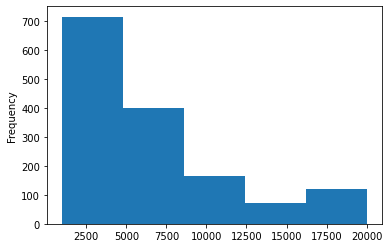

In [78]:
employees['MonthlyIncome'].plot.hist(bins=5);

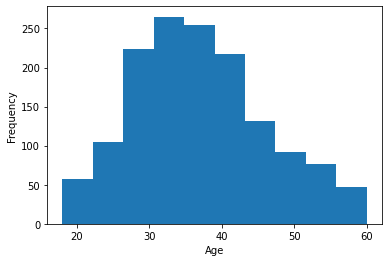

In [77]:
employees['Age'].plot.hist()
plt.xlabel('Age')
plt.show();

In [74]:
employees['MonthlyIncome'].min(), employees['MonthlyIncome'].max() 

(1009, 19999)

## Comparison Analysis


### Simple bar charts

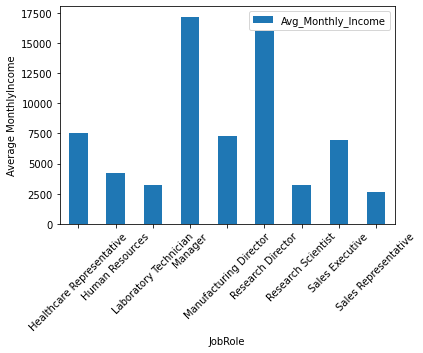

In [84]:
summary = employees.groupby(['JobRole']).agg(Avg_Monthly_Income=('MonthlyIncome', 'mean'))
summary = summary.reset_index()
summary.plot.bar(x='JobRole', y='Avg_Monthly_Income')
plt.xticks(rotation=45)
plt.ylabel('Average MonthlyIncome')
plt.show();

### Stacked bar charts

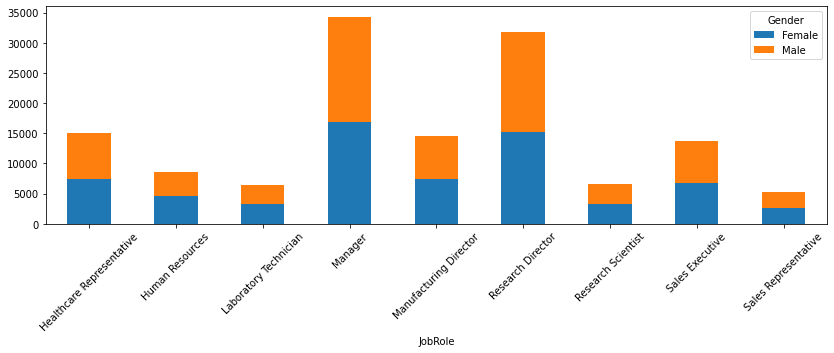

In [114]:
summary = employees.pivot_table(index='JobRole',
                                columns='Gender',
                                values='MonthlyIncome',
                                aggfunc='mean')
summary.plot.bar(stacked=True, figsize=(14,4))
plt.xticks(rotation=45)
#summary.plot.bar(stacked=True, subplots=True)
#summary.plot.bar()
plt.show();

### Exercise
Create a stacked bar with following details
- x: Department
- y: Avg MonthlyIncome
- Color: Marital Status

## Relationship Analysis

### Scatter plot

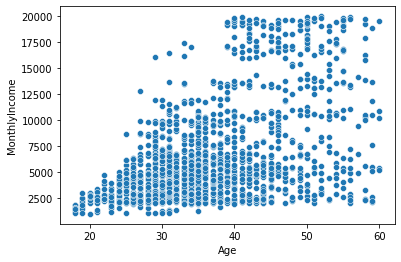

In [116]:
sns.scatterplot(data=employees, x='Age', y='MonthlyIncome')
plt.show();

In [117]:
# source: Introduction to statistical learning (ISLR) book
url = 'https://raw.githubusercontent.com/skathirmani/datasets/main/Advertising.csv'
adv = pd.read_csv(url)
adv.shape

(200, 4)

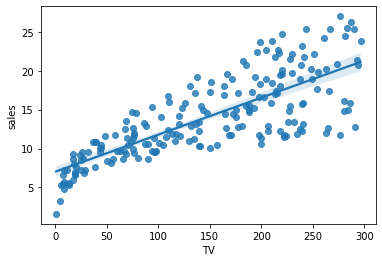

In [121]:
#sns.scatterplot(data=adv, x='TV', y='sales')
sns.regplot(data=adv, x='TV', y='sales')
plt.show();

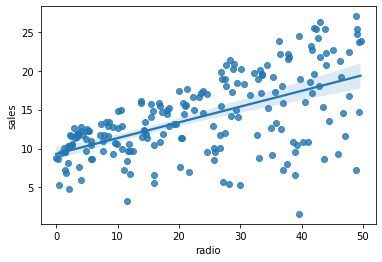

In [122]:
sns.regplot(data=adv, x='radio', y='sales')
plt.show();

### Subplots

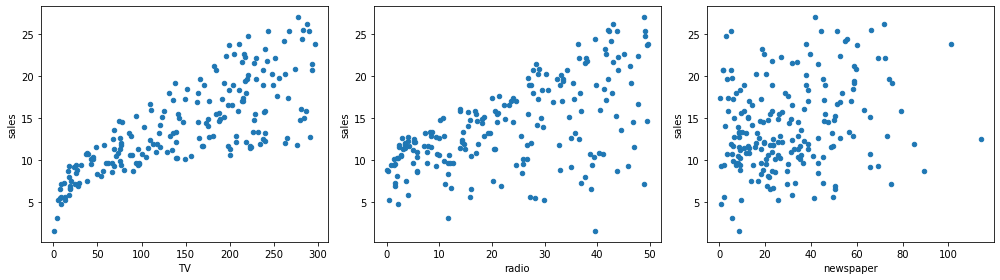

In [144]:
fig, axs = plt.subplots(1,3, figsize=(14,4))
adv.plot.scatter(x='TV', y='sales', ax=axs[0])
adv.plot.scatter(x='radio', y='sales', ax=axs[1])
adv.plot.scatter(x='newspaper', y='sales', ax=axs[2])
plt.tight_layout() # To avoid overlap between subplots
plt.show();

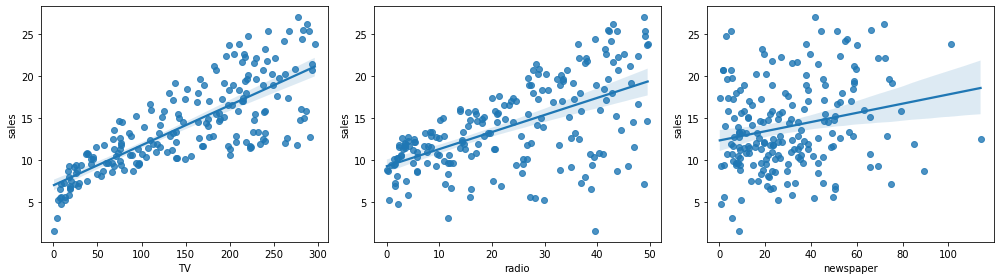

In [149]:
fig, axs = plt.subplots(1,3, figsize=(14,4))
sns.regplot(data=adv, x='TV', y='sales', ax=axs[0])
sns.regplot(data=adv, x='radio', y='sales', ax=axs[1])
sns.regplot(data=adv, x='newspaper', y='sales', ax=axs[2])
plt.tight_layout() # To avoid overlap between subplots
plt.show();

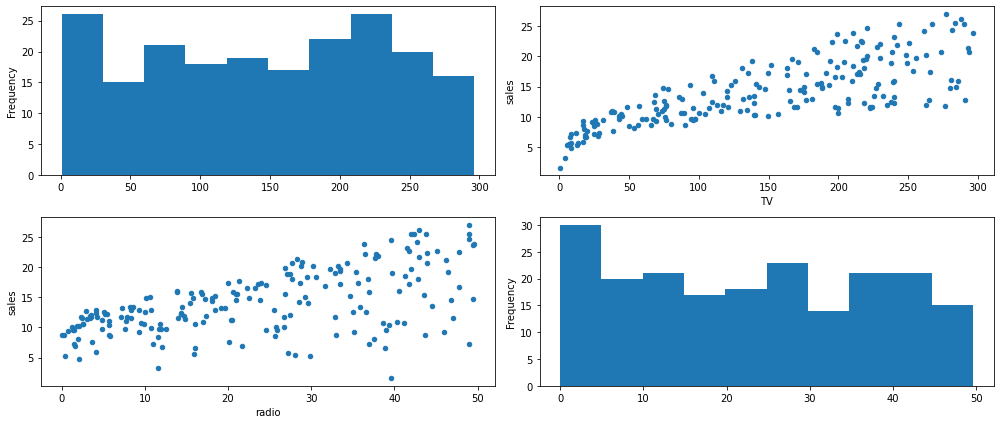

In [157]:
fig, axs = plt.subplots(2,2, figsize=(14,6))
adv['TV'].plot.hist(ax=axs[0][0])
adv.plot.scatter(x='TV', y='sales', ax=axs[0][1])
adv.plot.scatter(x='radio', y='sales', ax=axs[1][0])
adv['radio'].plot.hist(ax=axs[1][1])
plt.tight_layout() # To avoid overlap between subplots
plt.show();

### Pair plot

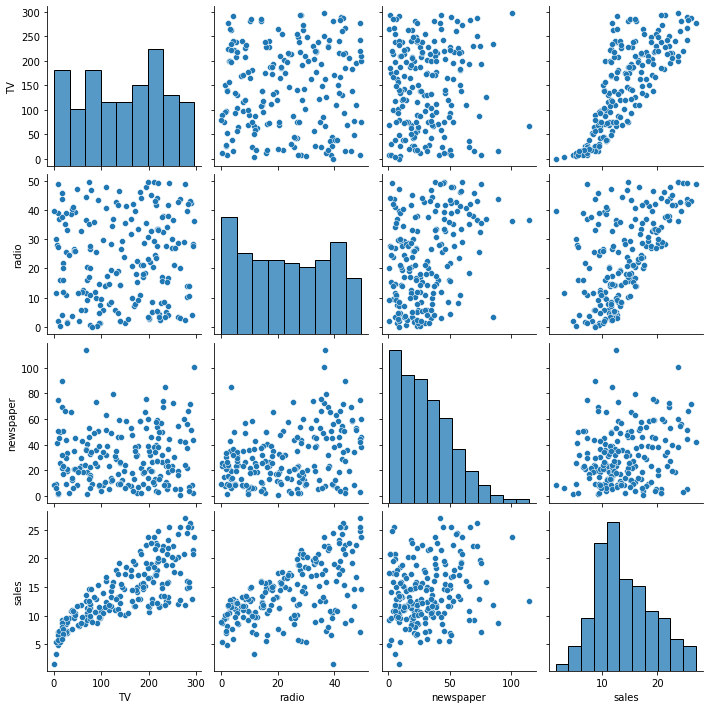

In [159]:
sns.pairplot(adv)
plt.show();

In [160]:
url = 'https://raw.githubusercontent.com/skathirmani/datasets/main/insurance.csv'
insurance = pd.read_csv(url)
insurance.shape

(1338, 7)

### Exercises
1. Draw scatterplot (as subplots) to identify the relationship between
  - age vs expenses
  - bmi vs expenses
2. Plot pairplot using the columns: ['age', 'bmi', 'children', 'expenses']

In [161]:
insurance.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


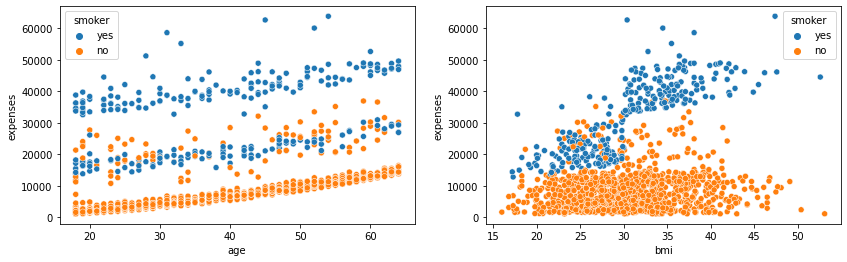

In [171]:
fig, axs = plt.subplots(1,2, figsize=(14,4))
sns.scatterplot(data=insurance, x='age', y='expenses', hue='smoker', ax=axs[0])
sns.scatterplot(data=insurance, x='bmi', y='expenses', hue='smoker', ax=axs[1])
plt.show();

In [168]:
#sns.pairplot(insurance, hue='smoker')

### Correlation matrix

In [173]:
insurance.corr()

,age,bmi,children,expenses
age,1.000000,0.109341,0.042469,0.299008
bmi,0.109341,1.000000,0.012645,0.198576
children,0.042469,0.012645,1.000000,0.067998
expenses,0.299008,0.198576,0.067998,1.000000


In [185]:
adv.corr()

,TV,radio,newspaper,sales
TV,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
newspaper,0.056648,0.354104,1.000000,0.228299
sales,0.782224,0.576223,0.228299,1.000000


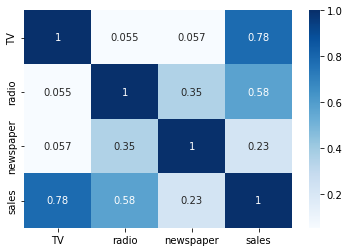

In [184]:
sns.heatmap(adv.corr(), cmap='Blues', annot=True)

## Overlapping charts

In [186]:
url = 'https://raw.githubusercontent.com/skathirmani/datasets/main/odi-batting.csv'
odi = pd.read_csv(url)
odi.shape

(55926, 8)

In [187]:
odi.head()

,Country,Player,Runs,ScoreRate,MatchDate,Ground,Versus,URL
0,Afghanistan,Mohammad Shahzad,118.0,97.52,2-16-2010,Sharjah CA Stadium,Canada,../Matches/MatchScorecard_ODI.asp?MatchCode=3087
1,Afghanistan,Mohammad Shahzad,110.0,99.09,9-1-2009,VRA Ground,Netherlands,../Matches/MatchScorecard_ODI.asp?MatchCode=3008
2,Afghanistan,Mohammad Shahzad,100.0,138.88,8-16-2010,Cambusdoon New Ground,Scotland,../Matches/MatchScorecard_ODI.asp?MatchCode=3164
3,Afghanistan,Mohammad Shahzad,82.0,75.92,7-10-2010,Hazelaarweg,Netherlands,../Matches/MatchScorecard_ODI.asp?MatchCode=3153
4,Afghanistan,Mohammad Shahzad,57.0,100.00,7-1-2010,Sportpark Westvliet,Canada,../Matches/MatchScorecard_ODI.asp?MatchCode=3135


In [189]:
odi['Date'] = pd.to_datetime(odi['MatchDate'], format='%m-%d-%Y')
odi['year'] = odi['Date'].dt.year

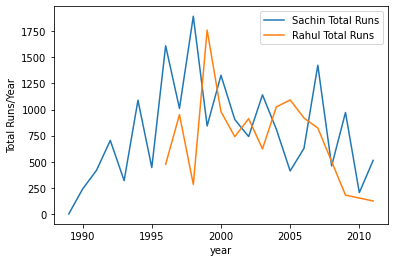

In [200]:
# yearwise runs scored by Sachin R Tendulkar
fig, axs = plt.subplots(1,1)
sachin = odi[odi['Player'] == 'Sachin R Tendulkar']
sachin.groupby('year')['Runs'].sum().plot.line(ax=axs)

# yearwise runs scored by Rahul Dravid
rahul = odi[odi['Player'] == 'Rahul Dravid']
rahul.groupby('year')['Runs'].sum().plot.line(ax=axs)
plt.legend(['Sachin Total Runs', 'Rahul Total Runs'])
plt.ylabel('Total Runs/Year')
plt.show();